# ARICast — Phase 1: EDA & Seasonal-Naive Baseline

**Goal.** Understand the structure of the two ARI series (trend, seasonality, weekly pattern),
then establish the **seasonal-naive baseline** — the bar every later model must clear.

The baseline is deliberately the first modeling step, not an afterthought: on strongly seasonal
data a model that cannot beat "last year's value" is not earning its complexity.

## 1. Setup & load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

PROCESSED = Path("../data/processed")
GEOGRAPHIES = ["United States", "California"]

def load(geo):
    fname = "ari_" + geo.lower().replace(" ", "_") + ".csv"
    return pd.read_csv(PROCESSED / fname, parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)

series = {g: load(g) for g in GEOGRAPHIES}
for g, s in series.items():
    print(f"{g:14s} {len(s)} rows  mean={s['y'].mean():.1f}%  range {s['y'].min():.1f}-{s['y'].max():.1f}%")

United States  1351 rows  mean=13.3%  range 7.1-26.6%
California     1351 rows  mean=12.6%  range 6.9-31.7%


## 2. Seasonal decomposition

Additive decomposition with a 365-day period separates trend, yearly seasonality, and residual.

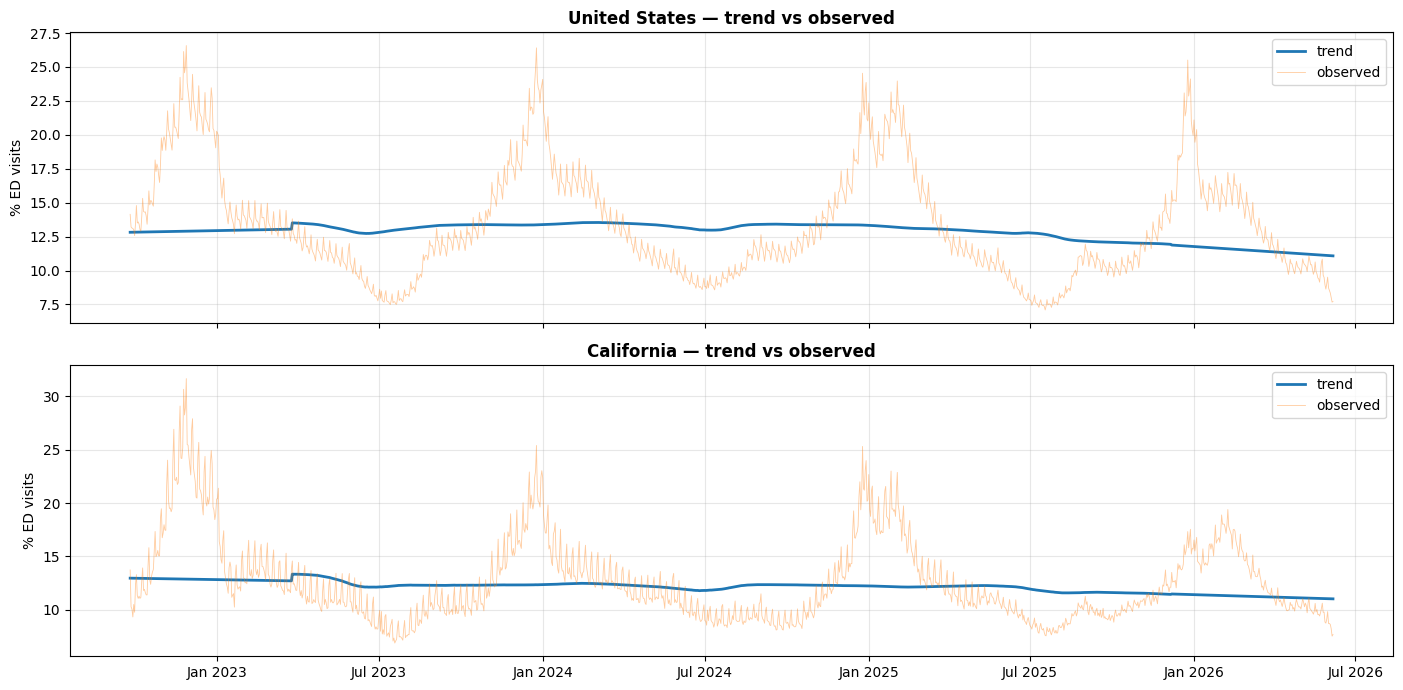

In [2]:
fig, axes = plt.subplots(len(GEOGRAPHIES), 1, figsize=(14, 7), sharex=True)
for ax, geo in zip(axes, GEOGRAPHIES):
    s = series[geo].set_index("ds")["y"]
    dec = seasonal_decompose(s, period=365, model="additive", extrapolate_trend="freq")
    ax.plot(dec.trend.index, dec.trend.values, label="trend", lw=2)
    ax.plot(s.index, s.values, lw=0.6, alpha=0.4, label="observed")
    ax.set_title(f"{geo} — trend vs observed", fontweight="bold")
    ax.set_ylabel("% ED visits"); ax.legend(loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout(); plt.show()

The trend component drifts **downward** over the sample — a post-pandemic normalization of
the ARI share. This matters for model choice later: a model that aggressively extrapolates this
falling trend will mis-forecast, which is exactly the failure we will see (and fix) in Phase 2.

## 3. Weekly pattern

Daily ED data carries a day-of-week effect (weekend vs weekday attendance mix).

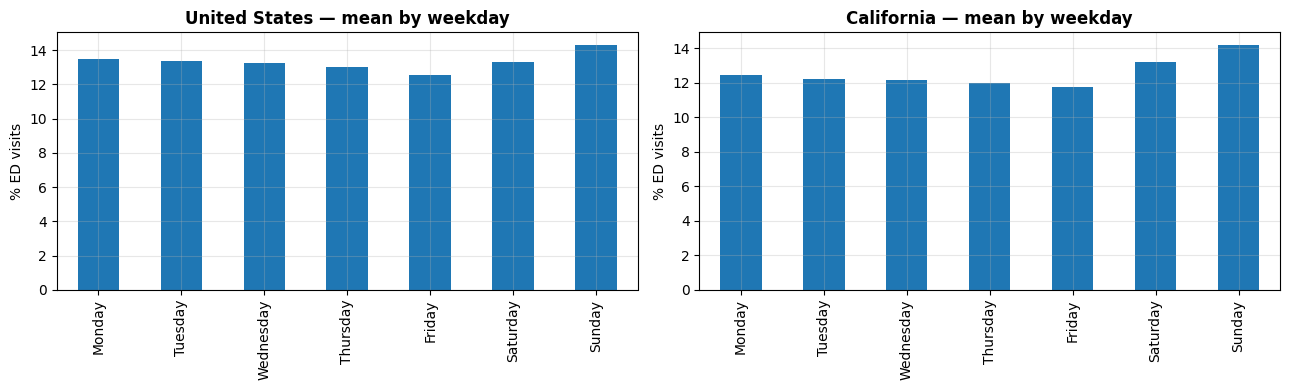

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, geo in zip(axes, GEOGRAPHIES):
    s = series[geo].copy()
    s["dow"] = s["ds"].dt.day_name()
    order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    s.groupby("dow")["y"].mean().reindex(order).plot(kind="bar", ax=ax)
    ax.set_title(f"{geo} — mean by weekday", fontweight="bold")
    ax.set_ylabel("% ED visits"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

## 4. Seasonal-naive baseline

The baseline predicts each day with the value exactly one year (365 days) earlier:
$$\hat{y}_t = y_{t-365}$$
We score it on the most recent 365-day holdout — the portion of the series that has a full
year of history behind every prediction.

In [4]:
def metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    err = y_true - y_pred
    return {"MAE": float(np.mean(np.abs(err))),
            "RMSE": float(np.sqrt(np.mean(err**2))),
            "MAPE": float(np.mean(np.abs(err / y_true)) * 100)}

rows = []
for geo in GEOGRAPHIES:
    s = series[geo].copy()
    s["yhat"] = s["y"].shift(365)
    holdout = s.dropna(subset=["yhat"]).iloc[-365:]
    m = metrics(holdout["y"], holdout["yhat"])
    m = {"series": geo, **{k: round(v, 2) for k, v in m.items()}}
    rows.append(m)
baseline = pd.DataFrame(rows)
print(baseline.to_string(index=False))

       series  MAE  RMSE  MAPE
United States 1.56  2.08 13.17
   California 1.34  1.93 11.14


These baseline figures (US MAPE ~13%, CA ~11% on the 365-day holdout) are the reference the
complex models are judged against in Phase 2 and 2b. **Important caveat carried forward:** this
single 365-day holdout is *not* the same as the rolling cross-validation used later — comparing a
single-holdout naive number against a CV model number is an apples-to-oranges trap the project
explicitly avoids by re-scoring every model, naive included, on identical CV windows in 02b.

## 4b. A second baseline: persistence

Seasonal-naive captures *seasonality* ("same day last year"). It is worth pairing with the
opposite trivial baseline — **persistence**, which captures *inertia* ("tomorrow looks like
today"): $\hat{y}_t = y_{c-1}$, the last observed value repeated across the horizon.

The two are strong at opposite horizons. We score persistence here on the same recent holdout
for a quick read; in 02b both baselines are re-scored on identical rolling CV windows.

In [5]:
persist_rows = []
for geo in GEOGRAPHIES:
    s = series[geo].copy()
    y = s["y"].values
    # persistence on the last 365 days: predict each day with the value the day before the
    # 365-day holdout began, in 1-step fashion (here: previous-day value)
    s["yhat_persist"] = s["y"].shift(1)
    h = s.dropna(subset=["yhat_persist"]).iloc[-365:]
    m = metrics(h["y"], h["yhat_persist"])
    persist_rows.append({"series": geo, **{k: round(v, 2) for k, v in m.items()}})
persist = pd.DataFrame(persist_rows)
print("1-step persistence (last 365 days):")
print(persist.to_string(index=False))

1-step persistence (last 365 days):
       series  MAE  RMSE  MAPE
United States 0.47  0.64  3.72
   California 0.46  0.60  3.93


On a 1-step read persistence looks excellent, because day-to-day change in an ED-visit
*proportion* is small. That is exactly why persistence becomes a serious short-horizon baseline
in 02b — and exactly why it collapses at long horizons, where "yesterday" is uninformative
about a day three months out.

## 5. Baseline forecast vs actual

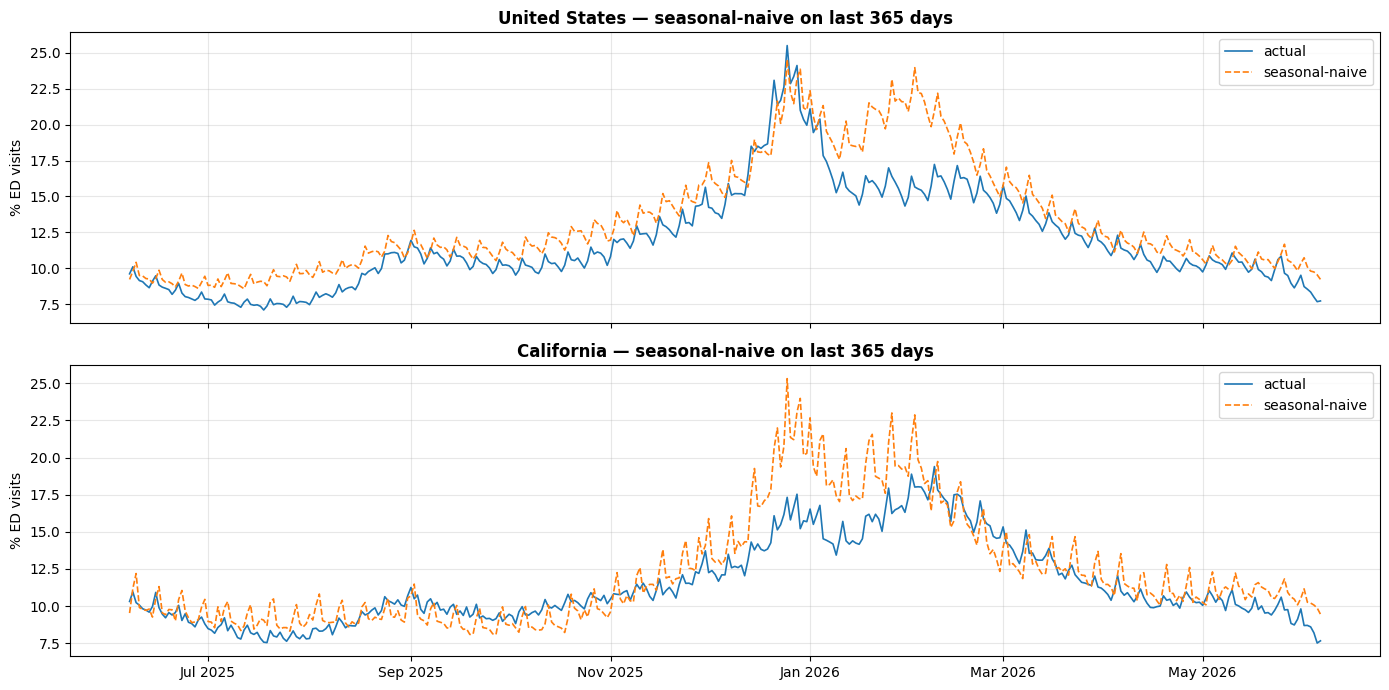

In [6]:
fig, axes = plt.subplots(len(GEOGRAPHIES), 1, figsize=(14, 7), sharex=True)
for ax, geo in zip(axes, GEOGRAPHIES):
    s = series[geo].copy()
    s["yhat"] = s["y"].shift(365)
    h = s.dropna(subset=["yhat"]).iloc[-365:]
    ax.plot(h["ds"], h["y"], label="actual", lw=1.2)
    ax.plot(h["ds"], h["yhat"], label="seasonal-naive", lw=1.2, ls="--")
    ax.set_title(f"{geo} — seasonal-naive on last 365 days", fontweight="bold")
    ax.set_ylabel("% ED visits"); ax.legend(loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout(); plt.show()

The naive forecast tracks the seasonal shape well but cannot react to year-over-year shifts
in peak height or timing — precisely the gap a good short-horizon model should close, and (as
Phase 2b shows) the gap ARIMA+Fourier closes at 7–14 days while Prophet does not.